## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load_config import load_config
from utils.load_data import load_pkl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.utils import resample

## Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)

In [5]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [6]:
meta = pd.DataFrame.from_records(list(meta))

## PCA

Normalize each spectrum

In [7]:
# axis=1 to work row by row
# keepdims=True keeps the dimensions needed for per-row normalization to work correctly
data_norm = (data - data.min(axis=1, keepdims=True)) / (
    data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

Reduce dimensionality (there are 6000 features)

In [ ]:
my_pca = PCA().fit(data_norm)

In [ ]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

In [ ]:
print(cumulative_explained_var)
print(cumulative_explained_var_ratio)

In [ ]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

In [ ]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.9) + 1
print(f"Number of components explaining 90% variance: {n_components}")

This indicates that 551 components are needed to account for 90% of the variance in our dataset. However, this is still a lot for t-SNE, so it is recommended to try and reduce the number of components

In [ ]:
possible_dims = [30, 50, 100]
for dim in possible_dims:
    pca = PCA(n_components=dim).fit(data_norm)
    print(f"Explained variance with {dim} components: {np.sum(pca.explained_variance_ratio_)}")

In [8]:
data_norm_pca = PCA(n_components=100).fit_transform(data_norm)

## t-SNE

In [9]:
my_tsne = TSNE(n_components=2)
data_tsne = my_tsne.fit_transform(data_norm_pca)

In [10]:
n_samples = 10000
X_pca_sub, X_tsne_sub, y_sub = resample(
    data_norm_pca, data_tsne, label, n_samples=n_samples, stratify=label)

tw = trustworthiness(X_pca_sub, X_tsne_sub, n_neighbors=30)
print(f"Trustworthiness (10k stratified sample): {tw:.3f}")

Trustworthiness (10k stratified sample): 0.990


## Visualization

### Label Encoding & DataFrame Creation  

In [11]:
# Identify unique labels
unique_labels = np.unique(label)
print(unique_labels)

# Assign a number to each label
label_to_idx = {}
for i in range(len(unique_labels)):
    label_to_idx[str(unique_labels[i])] = i
print(label_to_idx)

# Map label dataset 
encoded_label = np.array([label_to_idx[l] for l in label])
print(encoded_label)

['Enterobacter_cloacae_complex' 'Enterococcus_Faecium' 'Escherichia_Coli'
 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa' 'Staphylococcus_Aureus']
{'Enterobacter_cloacae_complex': 0, 'Enterococcus_Faecium': 1, 'Escherichia_Coli': 2, 'Klebsiella_Pneumoniae': 3, 'Pseudomonas_Aeruginosa': 4, 'Staphylococcus_Aureus': 5}
[3 3 3 ... 0 0 0]


In [12]:
# Create a DataFrame combining coordinates and metadata
tsne_df = pd.DataFrame({
    "x": data_tsne[:, 0],
    "y": data_tsne[:, 1],
    "species": label,
    "year": meta["year"].astype(str), 
    "hospital": meta["hospital"].astype(str)
})

tsne_df

,x,y,species,year,hospital
0,59.457626,8.284645,Klebsiella_Pneumoniae,2018,DRIAMS_B
1,59.926918,0.775965,Klebsiella_Pneumoniae,2018,DRIAMS_B
2,63.415424,3.864093,Klebsiella_Pneumoniae,2018,DRIAMS_B
3,58.483208,1.249321,Klebsiella_Pneumoniae,2018,DRIAMS_B
4,59.673981,24.164124,Klebsiella_Pneumoniae,2018,DRIAMS_B
...,...,...,...,...,...
39776,7.044489,34.424473,Enterobacter_cloacae_complex,2017,DRIAMS_A
39777,14.071212,12.991244,Enterobacter_cloacae_complex,2018,DRIAMS_C
39778,6.673496,23.127748,Enterobacter_cloacae_complex,2018,DRIAMS_C
39779,13.451689,13.550250,Enterobacter_cloacae_complex,2018,DRIAMS_C


### Palettes and Label Orders

In [13]:
# Define categorical orders
species_sorted = sorted(tsne_df["species"].unique())
years_sorted = sorted(tsne_df["year"].unique(), key=lambda x: int(x))
hospitals_sorted = sorted(tsne_df["hospital"].unique())

# Base palette
tab10 = sns.color_palette("tab10")

# Species palette
species_color_map = {
    "Enterobacter_cloacae_complex": tab10[5],  
    "Enterococcus_Faecium": tab10[4],         
    "Escherichia_Coli": tab10[2],             
    "Klebsiella_Pneumoniae": tab10[3],         
    "Pseudomonas_Aeruginosa": tab10[0],       
    "Staphylococcus_Aureus": tab10[1],         
}
species_palette_dict = {sp: species_color_map[sp] for sp in species_sorted}

# Year palette (temporal order)
palette_year = sns.color_palette("tab10", len(years_sorted))
palette_year_dict = {y: palette_year[i] for i, y in enumerate(years_sorted)}

# Hospital palette (alphabetical order)
palette_hosp = sns.color_palette("tab10", len(hospitals_sorted))
palette_hosp_dict = {h: palette_hosp[i] for i, h in enumerate(hospitals_sorted)}

### Global t-SNE — Visualization by Species
Displays the overall t-SNE embedding colored by species to assess inter-species separation in spectral space.

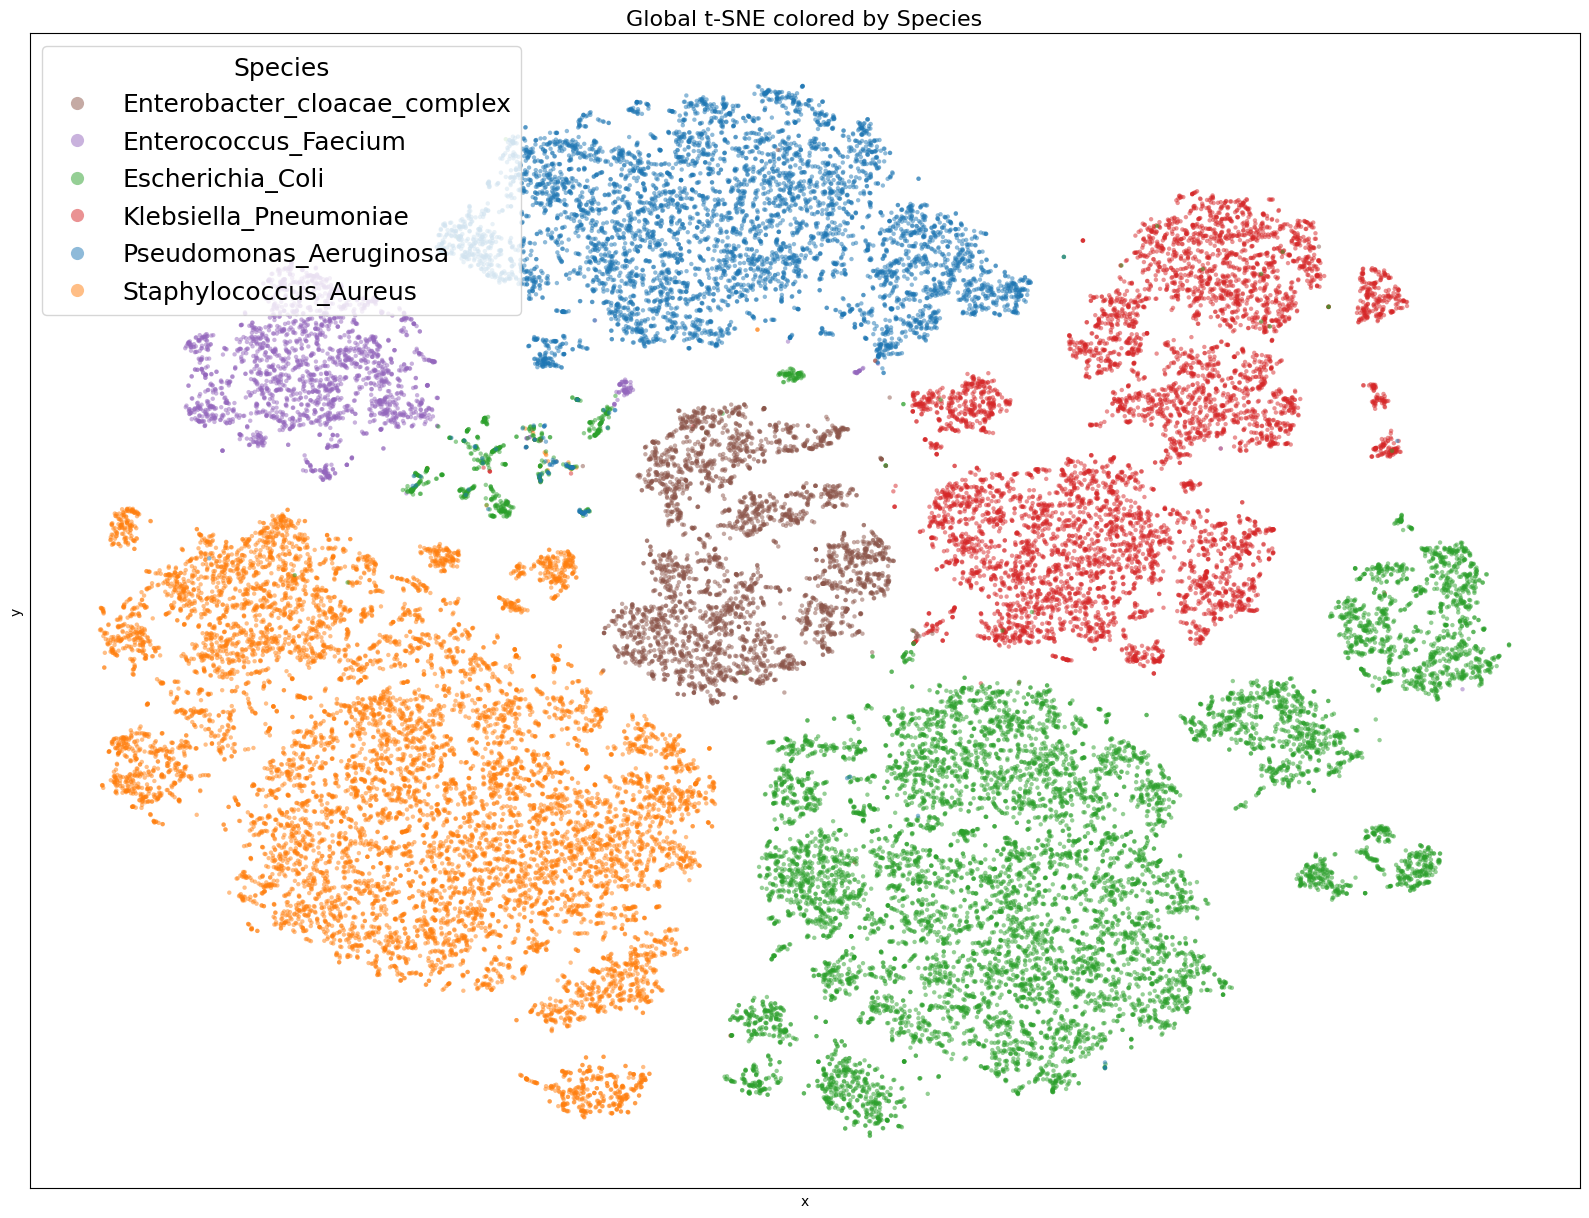

In [14]:
fig, ax = plt.subplots(figsize=(20, 15))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="species", hue_order=species_sorted,
    palette=species_palette_dict,
    s=10, linewidth=0, ax=ax, alpha=0.5
)
ax.set_title("Global t-SNE colored by Species", fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Species", title_fontsize= 18, fontsize=18, markerscale=3)
plt.show()

### Global t-SNE — Visualization by Year
Shows the global temporal distribution of the dataset, coloring each sample by acquisition year to detect potential time shifts.


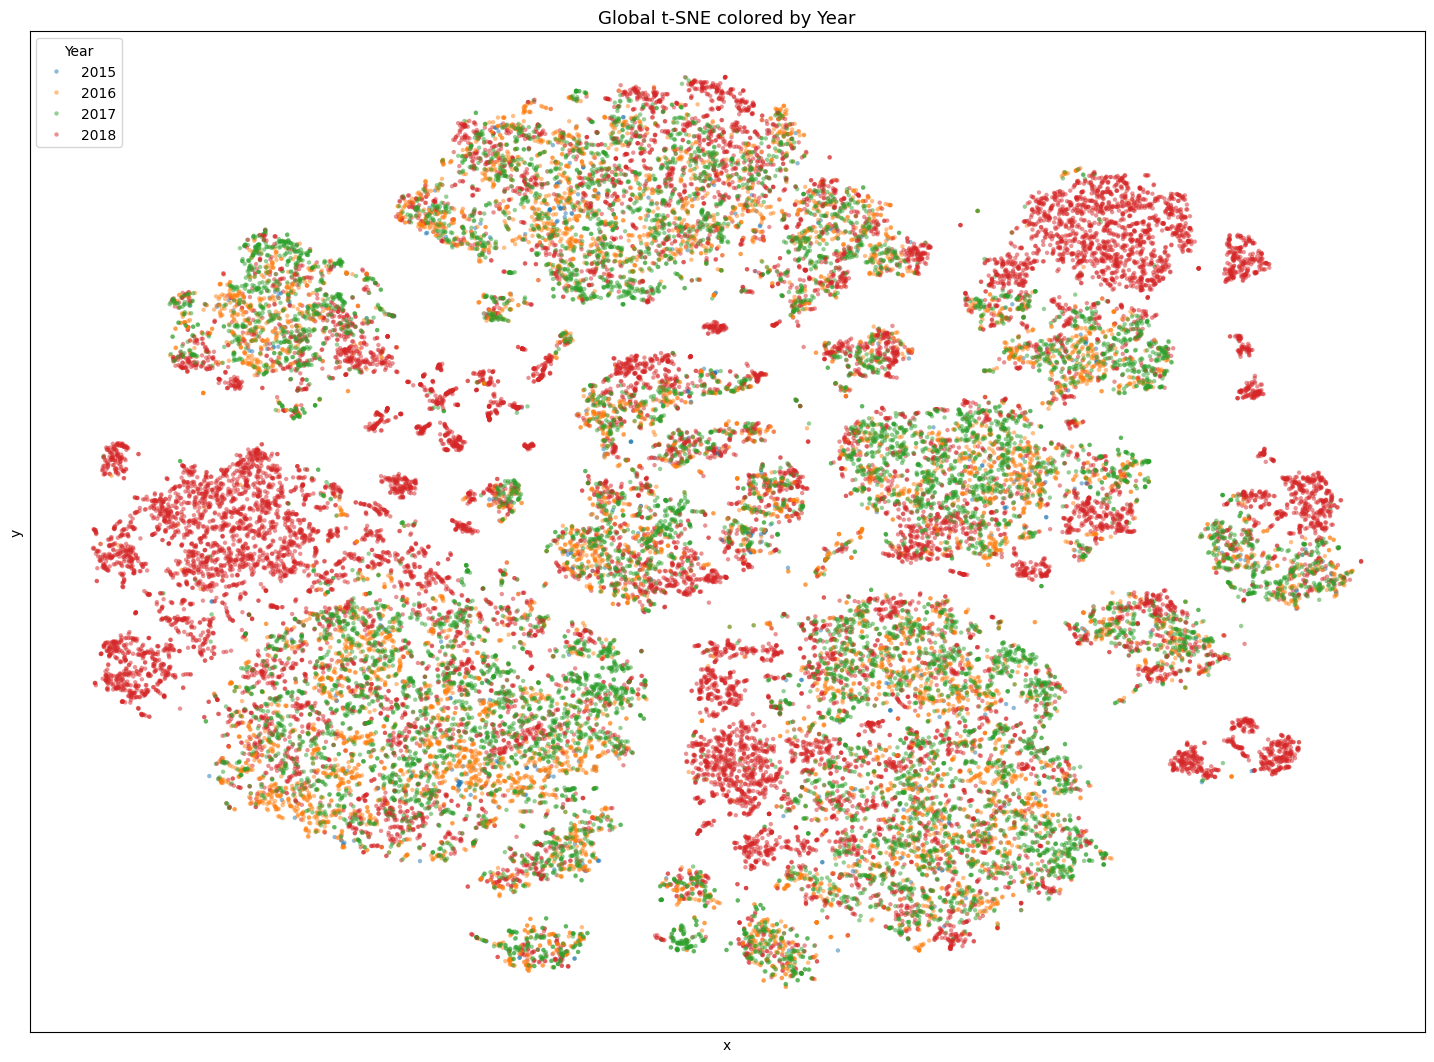

In [15]:
fig, ax = plt.subplots(figsize=(18, 13))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="year", hue_order=years_sorted,
    palette=palette_year_dict,
    s=10, linewidth=0, ax=ax, alpha=0.5
)
ax.set_title("Global t-SNE colored by Year", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Year")
plt.show()

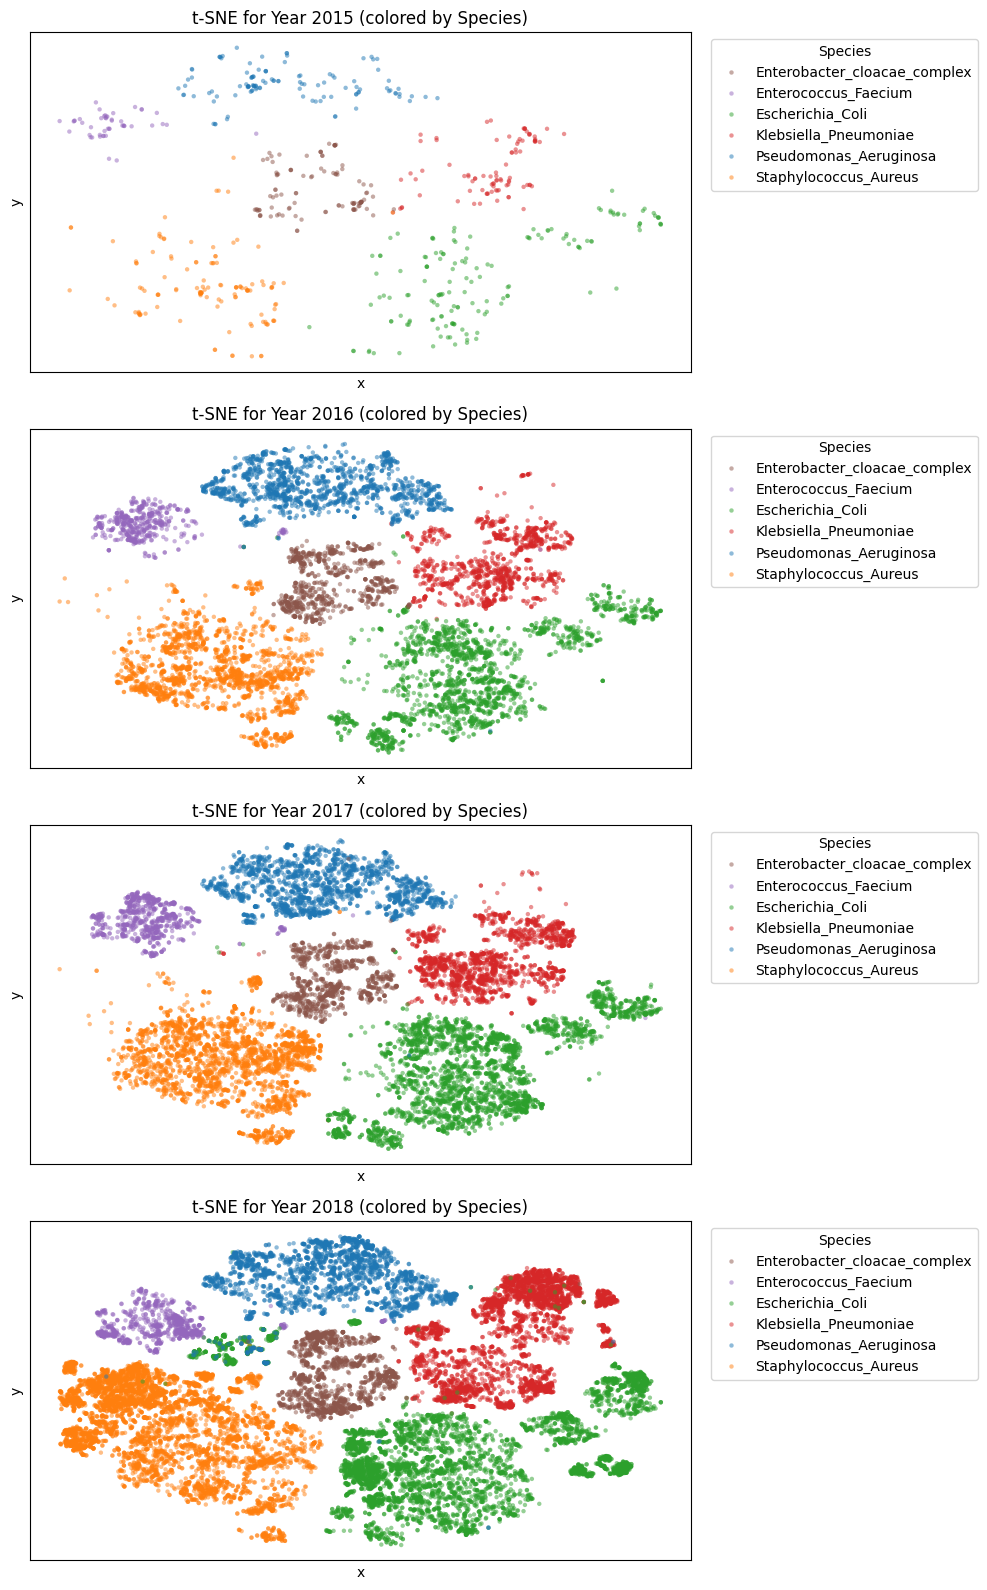

In [16]:
fig, axes = plt.subplots(len(years_sorted), 1, figsize=(10, 4 * len(years_sorted)))

for i, year in enumerate(years_sorted):
    subset = tsne_df[tsne_df["year"] == year]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="species",
        hue_order=species_sorted,
        palette=species_palette_dict,
        s=10, linewidth=0, ax=axes[i], alpha=0.5
    )
    axes[i].set_title(f"t-SNE for Year {year} (colored by Species)", fontsize=12)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Species")
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.tight_layout()
plt.show()

### Global t-SNE — Visualization by Hospital
Displays the overall embedding colored by hospital to reveal potential inter-hospital domain shifts.

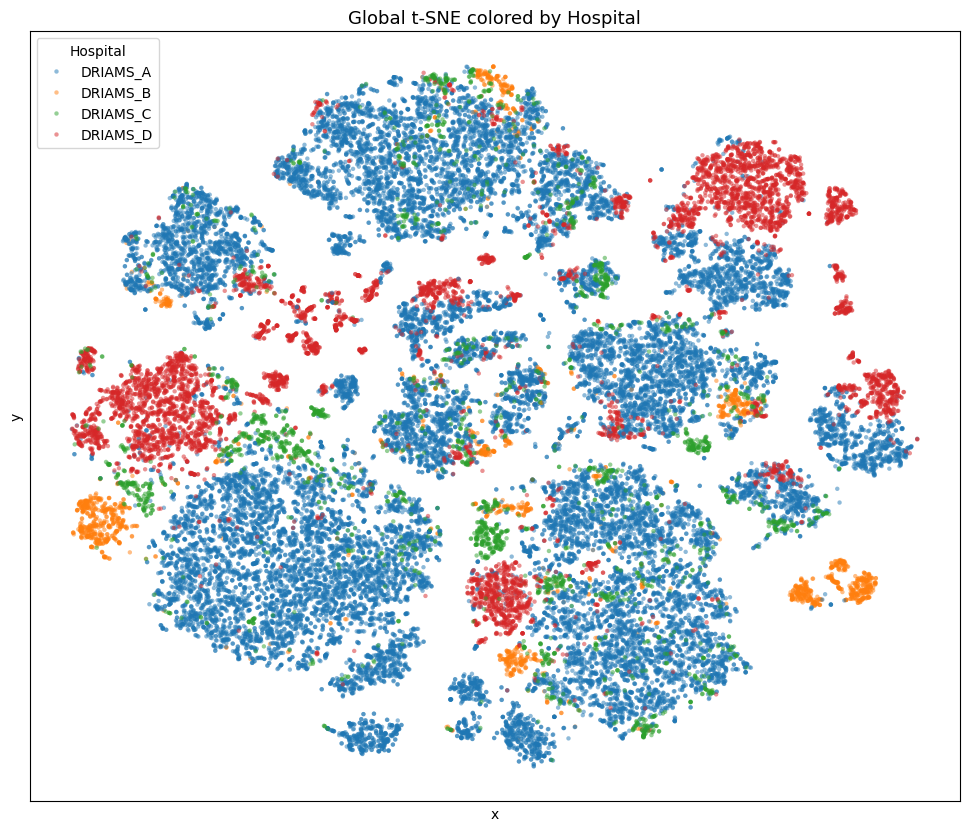

In [17]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="hospital", hue_order=hospitals_sorted,
    palette=palette_hosp_dict,
    s=10, alpha=0.5, linewidth=0, ax=ax
)
ax.set_title("Global t-SNE colored by Hospital", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Hospital")
plt.show()

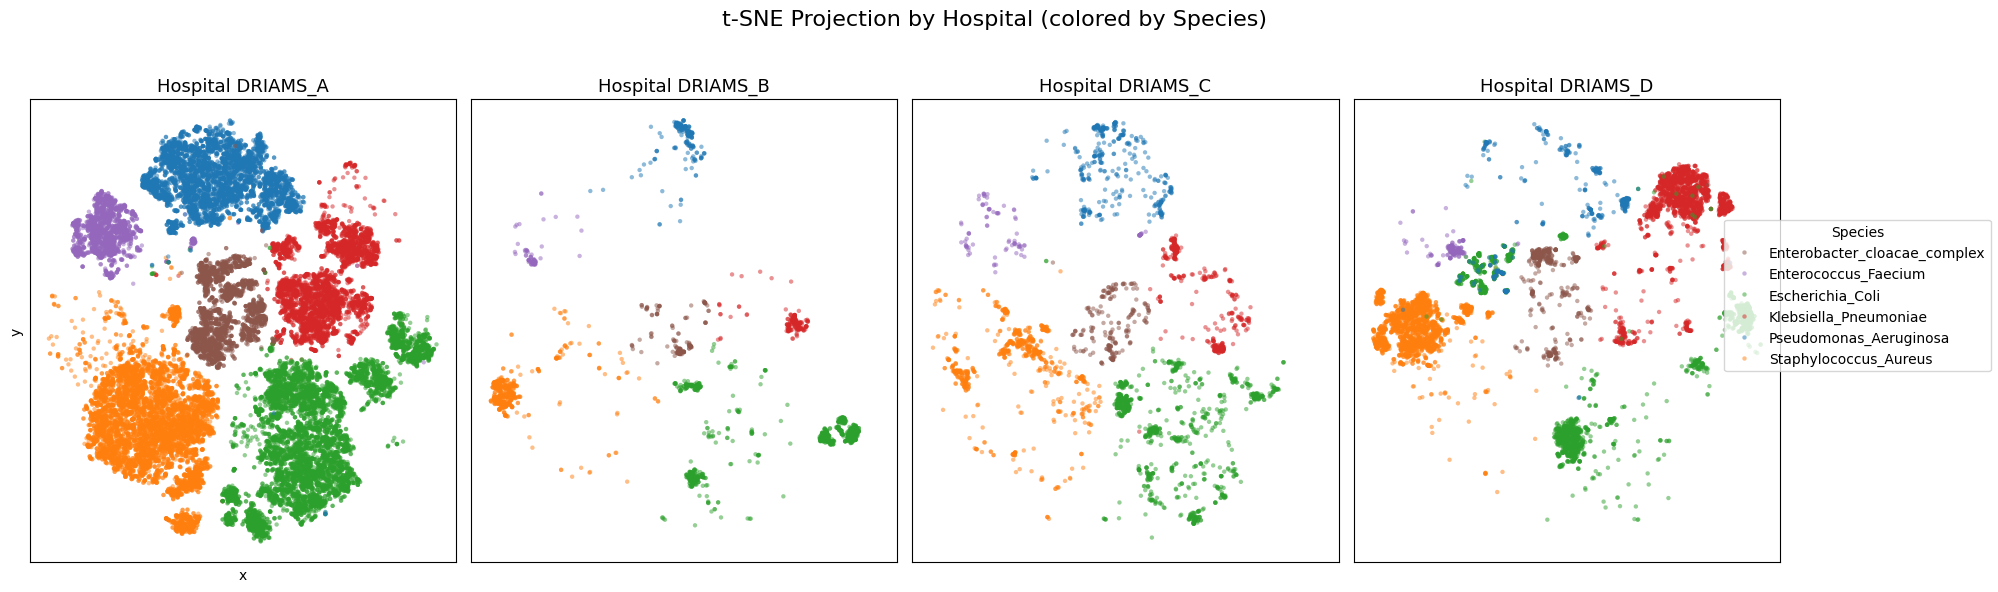

In [18]:
fig, axes = plt.subplots(1, len(hospitals_sorted), figsize=(5 * len(hospitals_sorted), 6), sharex=True, sharey=True)
axes = np.array(axes).flatten()

for i, hosp in enumerate(hospitals_sorted):
    subset = tsne_df[tsne_df["hospital"] == hosp]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="species",
        hue_order=species_sorted,
        palette=species_palette_dict,
        s=10, linewidth=0, ax=axes[i], alpha=0.5
    )
    axes[i].set_title(f"Hospital {hosp}", fontsize=13)
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Species")

plt.suptitle("t-SNE Projection by Hospital (colored by Species)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### t-SNE per Species — Global Embedding colored by Hospital
Shows the global embedding filtered by species and colored by hospital to reveal intra-species domain shifts.


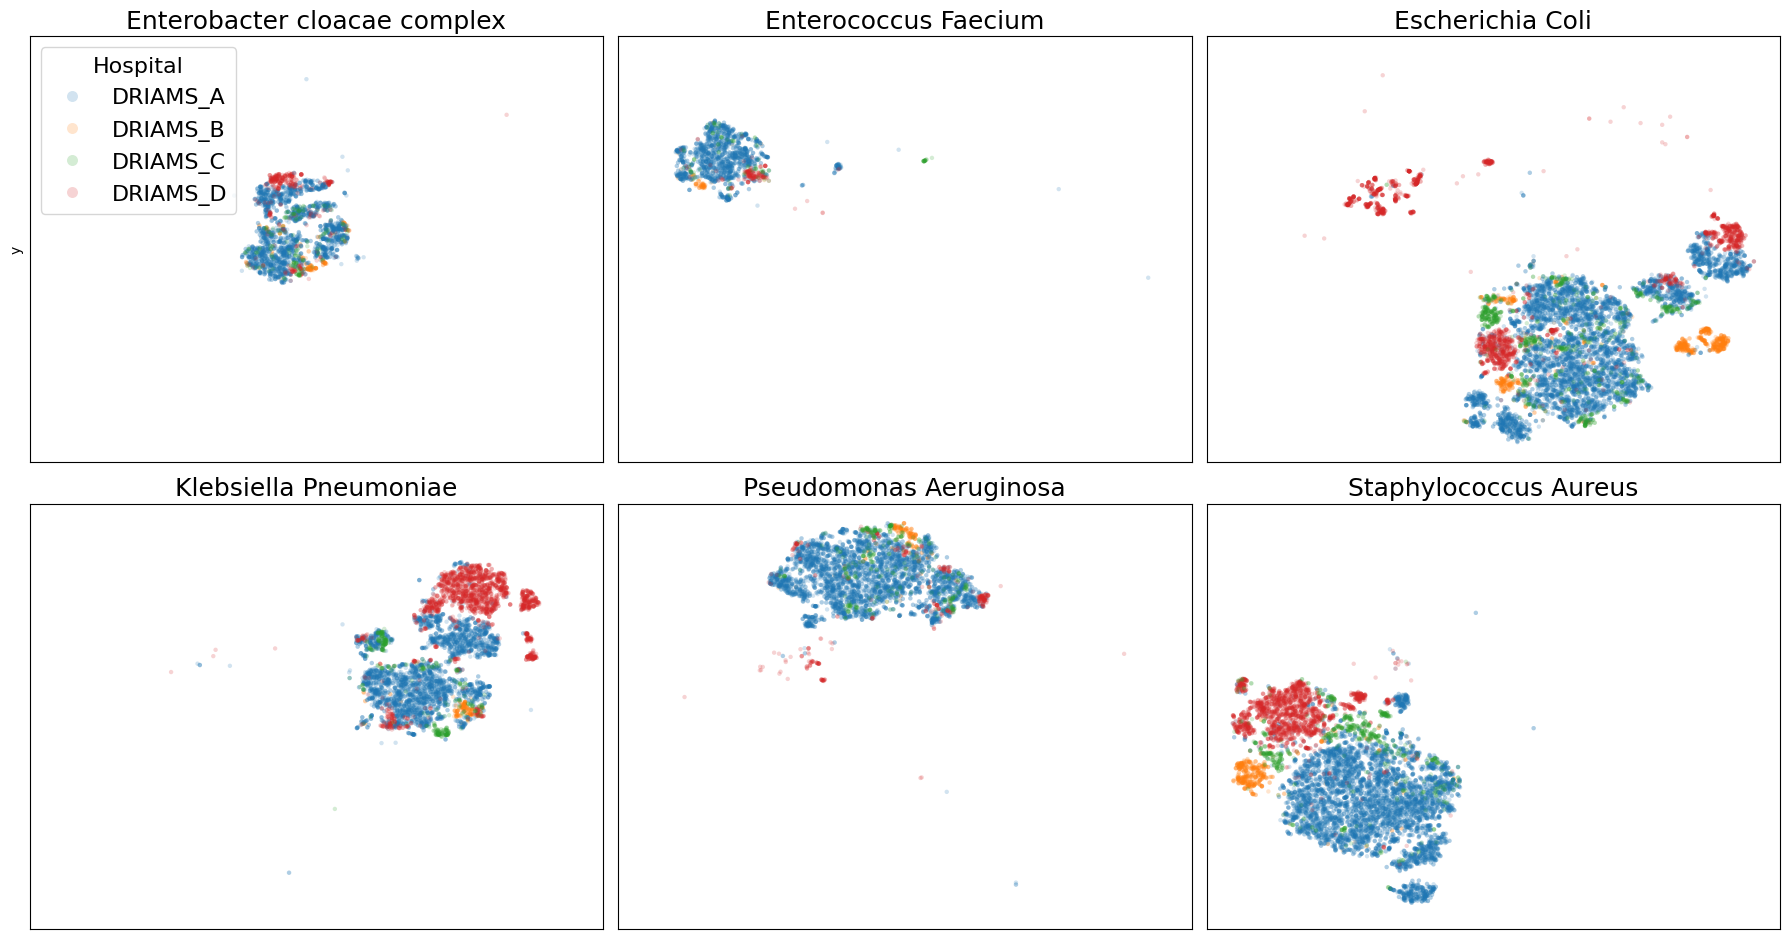

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    subset = tsne_df[tsne_df["species"] == sp]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="hospital",
        hue_order=hospitals_sorted,
        palette=palette_hosp_dict,
        s=10, linewidth=0, ax=axes[i], alpha=0.2
    )
    axes[i].set_title(sp.replace("_", " "), fontsize=18)
    axes[i].set_xticks([]); axes[i].set_yticks([])

    # Mostrar la leyenda solo en el primer subplot
    if i == 0:
        axes[i].legend(
            loc="upper left",
            title="Hospital",
            title_fontsize=16,
            fontsize=16,
            markerscale=2.5,
        )
    else:
        axes[i].legend_.remove()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

#plt.suptitle("t-SNE per Species — colored by Hospital", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Independent t-SNE per Species — Inter-Hospital Domain Shift
Trains an independent t-SNE for each species, coloring points by hospital, to visually assess intra-species domain shifts across hospitals.


In [23]:
tsne_results = {} 

species_sorted = sorted(np.unique(label))
palette_hosp = sns.color_palette("tab10", len(meta["hospital"].unique()))

for sp in species_sorted:
    mask = (label == sp)
    X = data_norm[mask]
    y_hosp = meta.loc[mask, "hospital"].values

    # PCA 
    X_pca = PCA(n_components=50).fit_transform(X)

    # t-SNE
    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X_pca)

    # Store in dictionary
    tsne_results[sp] = {
        "embedding": X_tsne,
        "hospital": y_hosp
    }

print(f"Stored {len(tsne_results)} t-SNE embeddings (one per species).")

Stored 6 t-SNE embeddings (one per species).


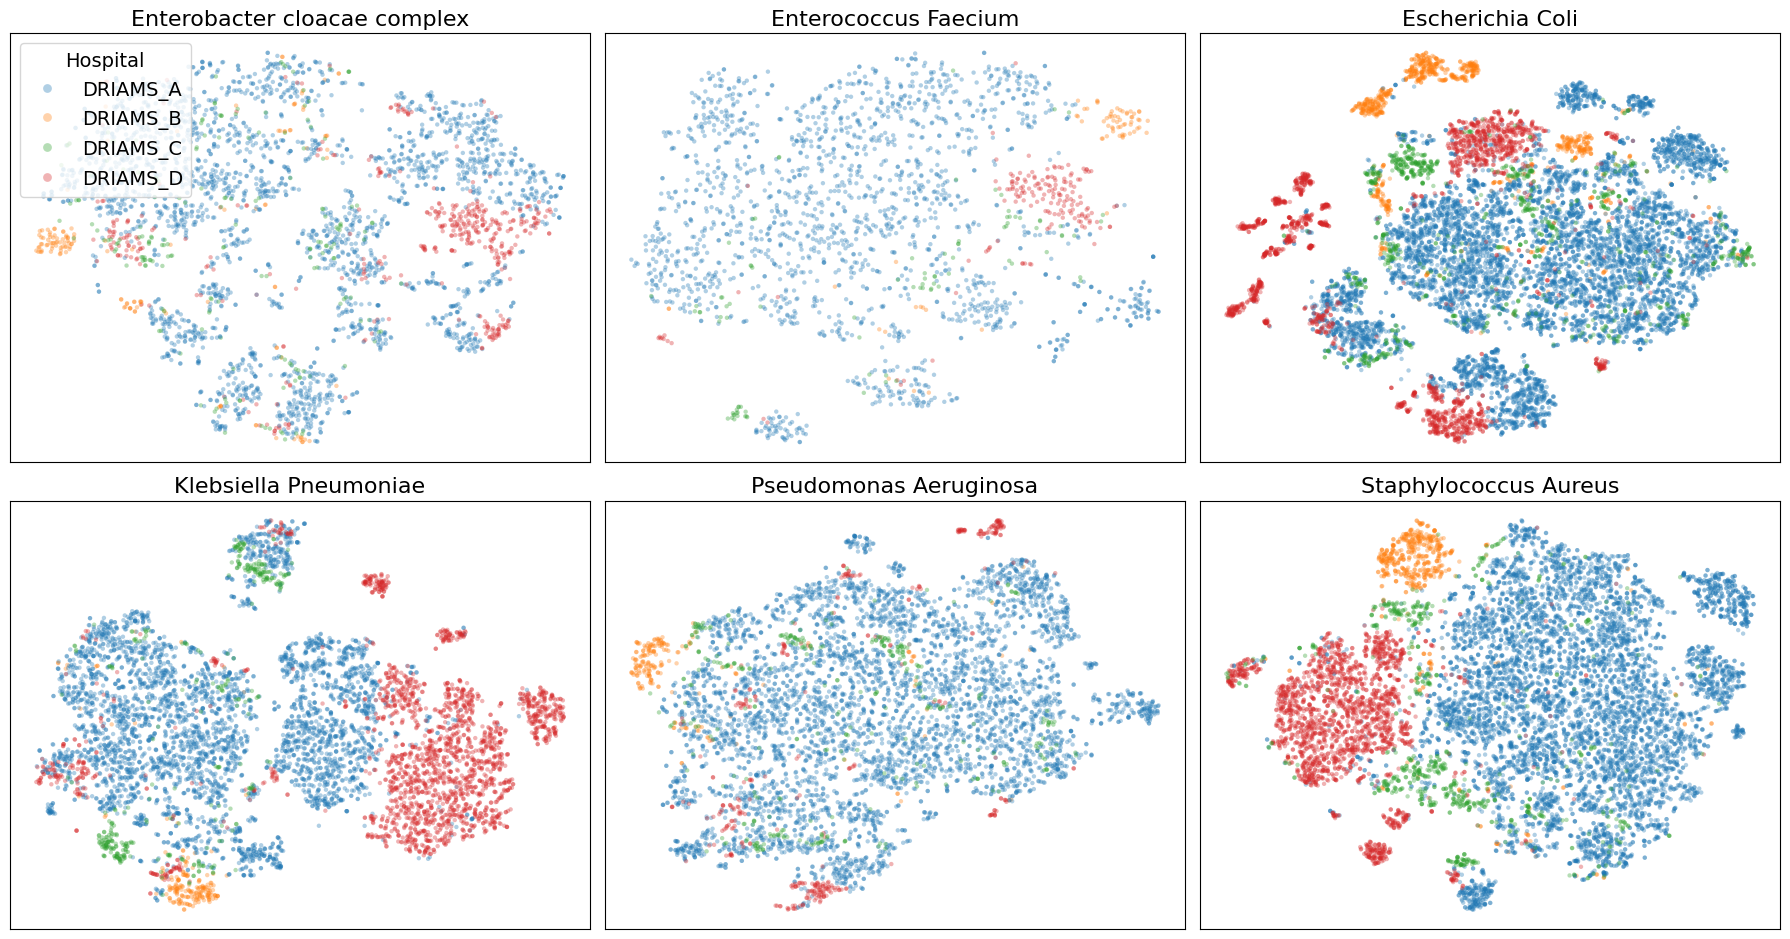

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    data_sp = tsne_results[sp]
    X_tsne = data_sp["embedding"]
    y_hosp = data_sp["hospital"]

    df_sp = pd.DataFrame({
        "x": X_tsne[:, 0],
        "y": X_tsne[:, 1],
        "hospital": y_hosp
    })

    sns.scatterplot(
        data=df_sp, x="x", y="y",
        hue="hospital",
        hue_order=hospitals_sorted,
        palette=palette_hosp_dict,
        s=10, linewidth=0, ax=axes[i], alpha=0.35
    )

    axes[i].set_title(sp.replace("_", " "), fontsize=16)
    axes[i].set_xticks([]); axes[i].set_yticks([]); axes[i].set_xlabel(""); axes[i].set_ylabel("")

    if i == 0:
        leg = axes[i].legend(
            title="Hospital",
            fontsize=14,
            title_fontsize=14,
            loc="upper left",
            markerscale=2.0,)
    else:
        axes[i].legend_.remove()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

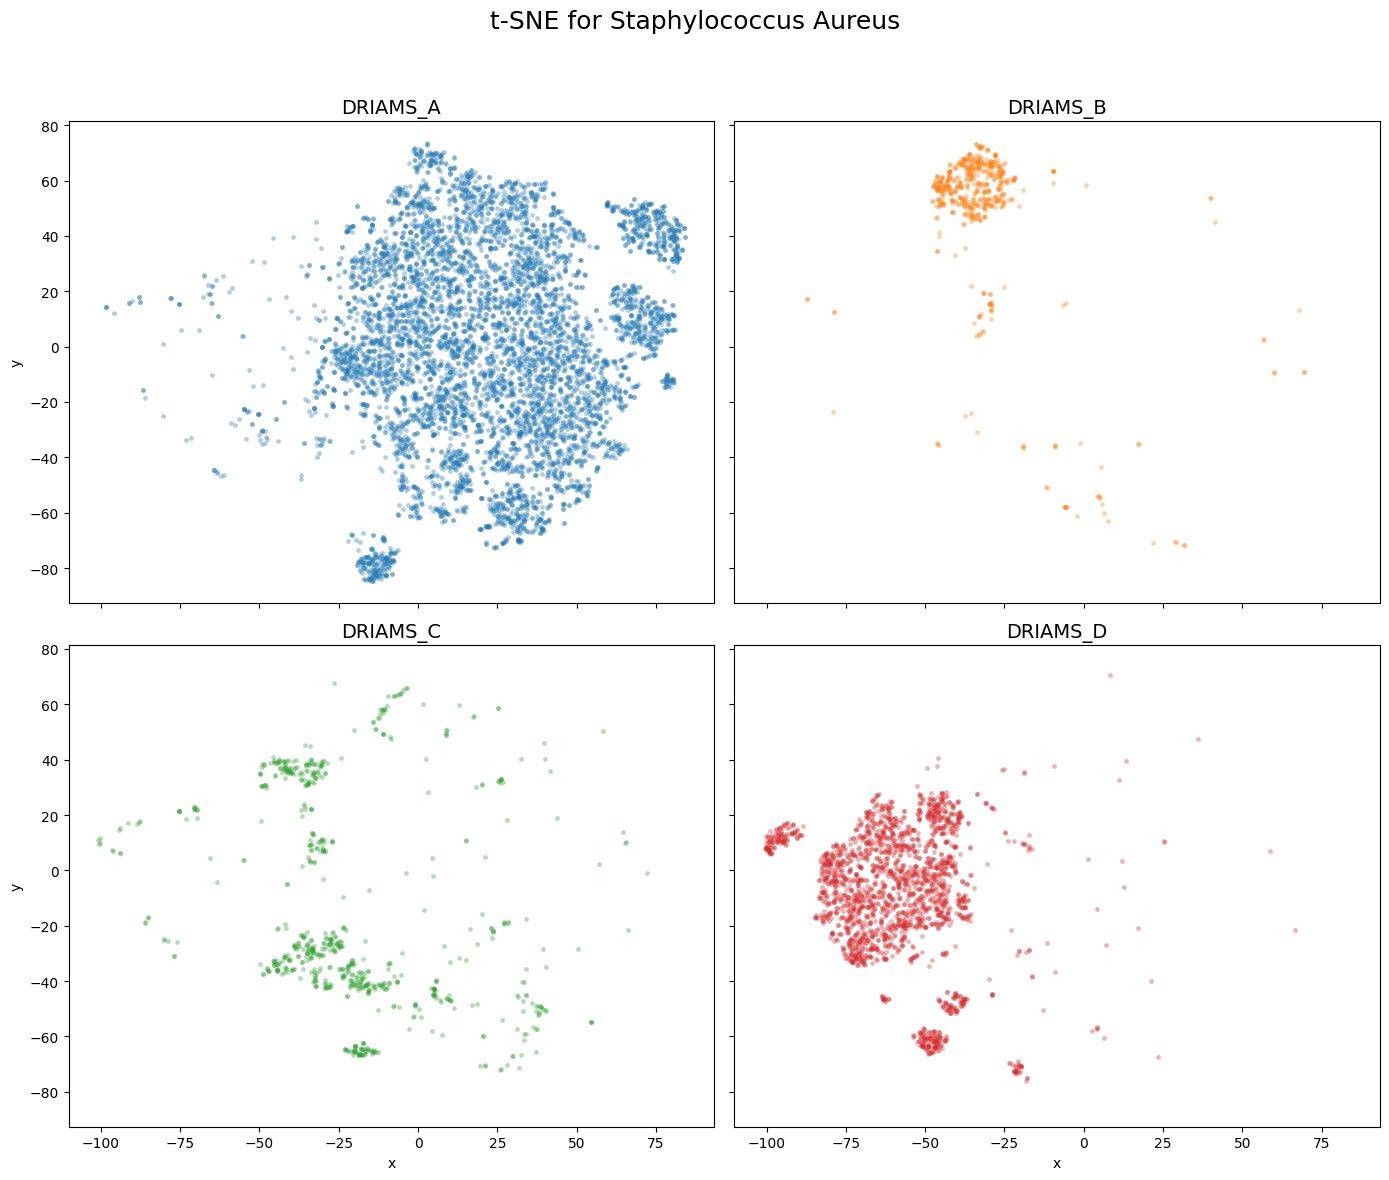

In [32]:
sp = "Staphylococcus_Aureus"  

data_sp = tsne_results[sp]
X_tsne = data_sp["embedding"]
y_hosp = data_sp["hospital"]

df_sp = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "hospital": y_hosp
})

hospitals_sorted = sorted(df_sp["hospital"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, hosp in enumerate(hospitals_sorted):
    subset = df_sp[df_sp["hospital"] == hosp]

    sns.scatterplot(
        data=subset,
        x="x", y="y",
        s=12, linewidth=0,
        alpha=0.35,
        color=palette_hosp_dict[hosp], 
        ax=axes[i]
    )

    axes[i].set_title(f"{hosp}", fontsize=14)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"t-SNE for {sp.replace('_',' ')}", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

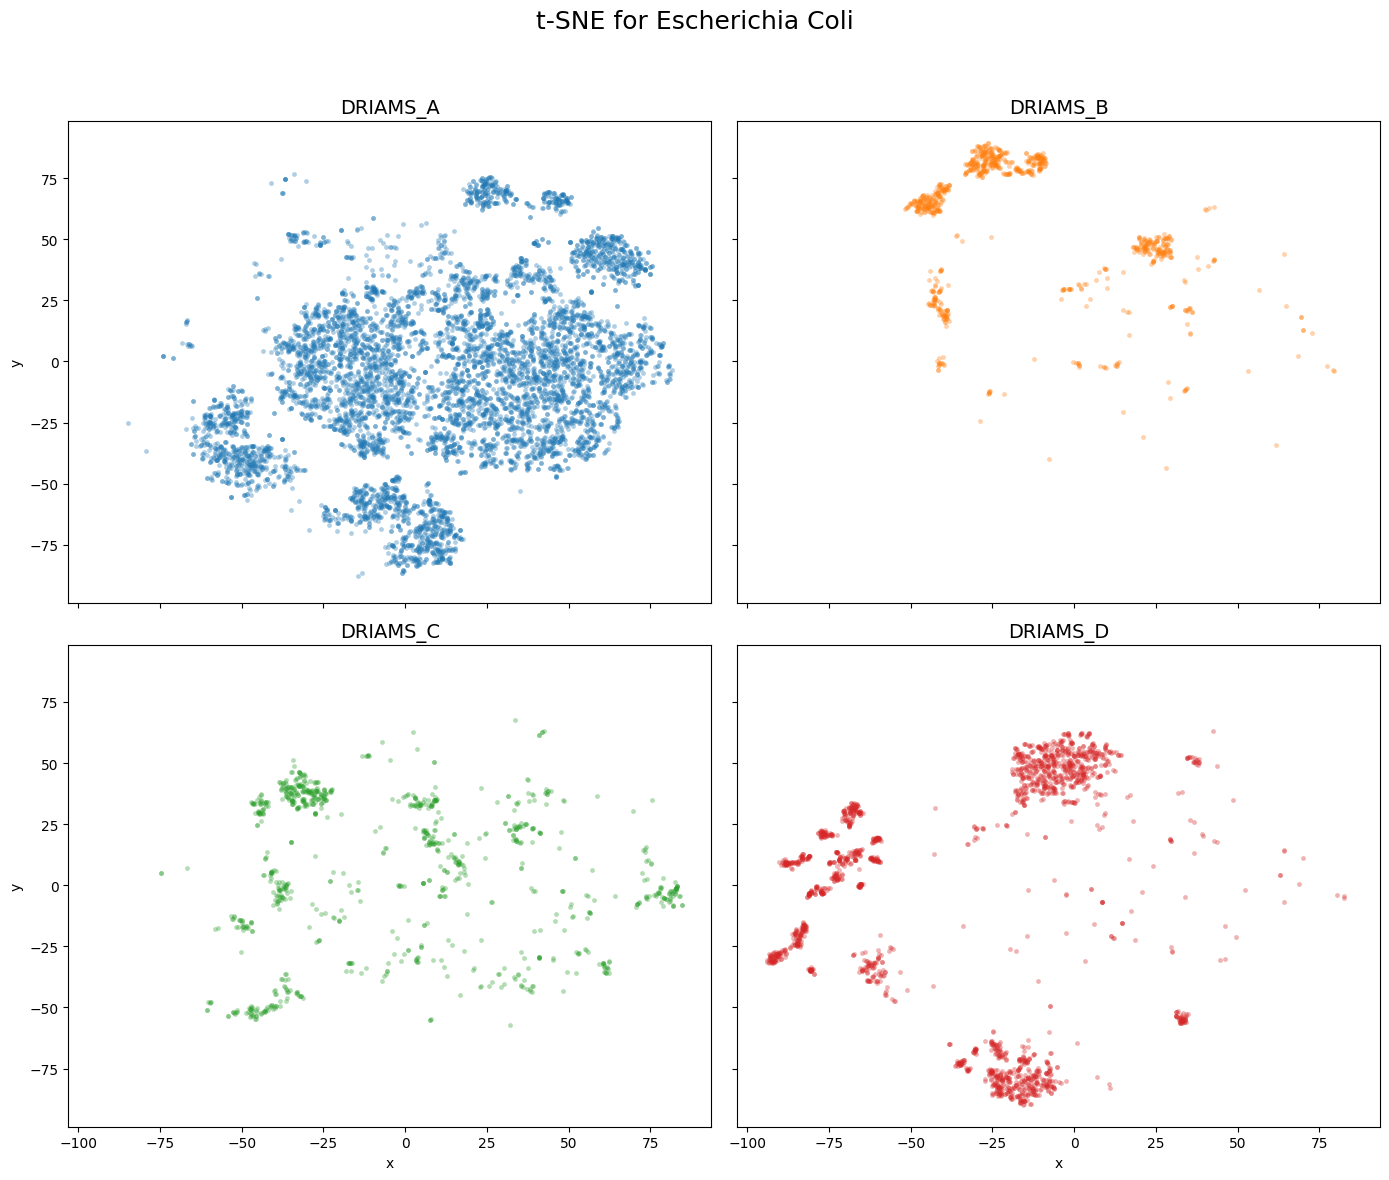

In [36]:
sp = "Escherichia_Coli"  

data_sp = tsne_results[sp]
X_tsne = data_sp["embedding"]
y_hosp = data_sp["hospital"]

df_sp = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "hospital": y_hosp
})

hospitals_sorted = sorted(df_sp["hospital"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, hosp in enumerate(hospitals_sorted):
    subset = df_sp[df_sp["hospital"] == hosp]

    sns.scatterplot(
        data=subset,
        x="x", y="y",
        s=12, linewidth=0,
        alpha=0.35,
        color=palette_hosp_dict[hosp], 
        ax=axes[i]
    )

    axes[i].set_title(f"{hosp}", fontsize=14)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"t-SNE for {sp.replace('_',' ')}", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Independent t-SNE per Species — Temporal Distribution Analysis
Independent t-SNE per species colored by year, revealing potential intra-species time shifts in spectral representations across acquisition years.

In [25]:
tsne_results_year = {}
species_sorted = sorted(np.unique(label))
palette_year = sns.color_palette("tab10", len(meta["year"].unique()))

for sp in species_sorted:
    mask = (label == sp)
    X = data_norm[mask]
    y_year = meta.loc[mask, "year"].astype(str).values

    X_pca = PCA(n_components=50).fit_transform(X)

    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X_pca)

    tsne_results_year[sp] = {
        "embedding": X_tsne,
        "year": y_year
    }

print(f"Stored {len(tsne_results_year)} t-SNE embeddings (one per species, colored by year).")

Stored 6 t-SNE embeddings (one per species, colored by year).


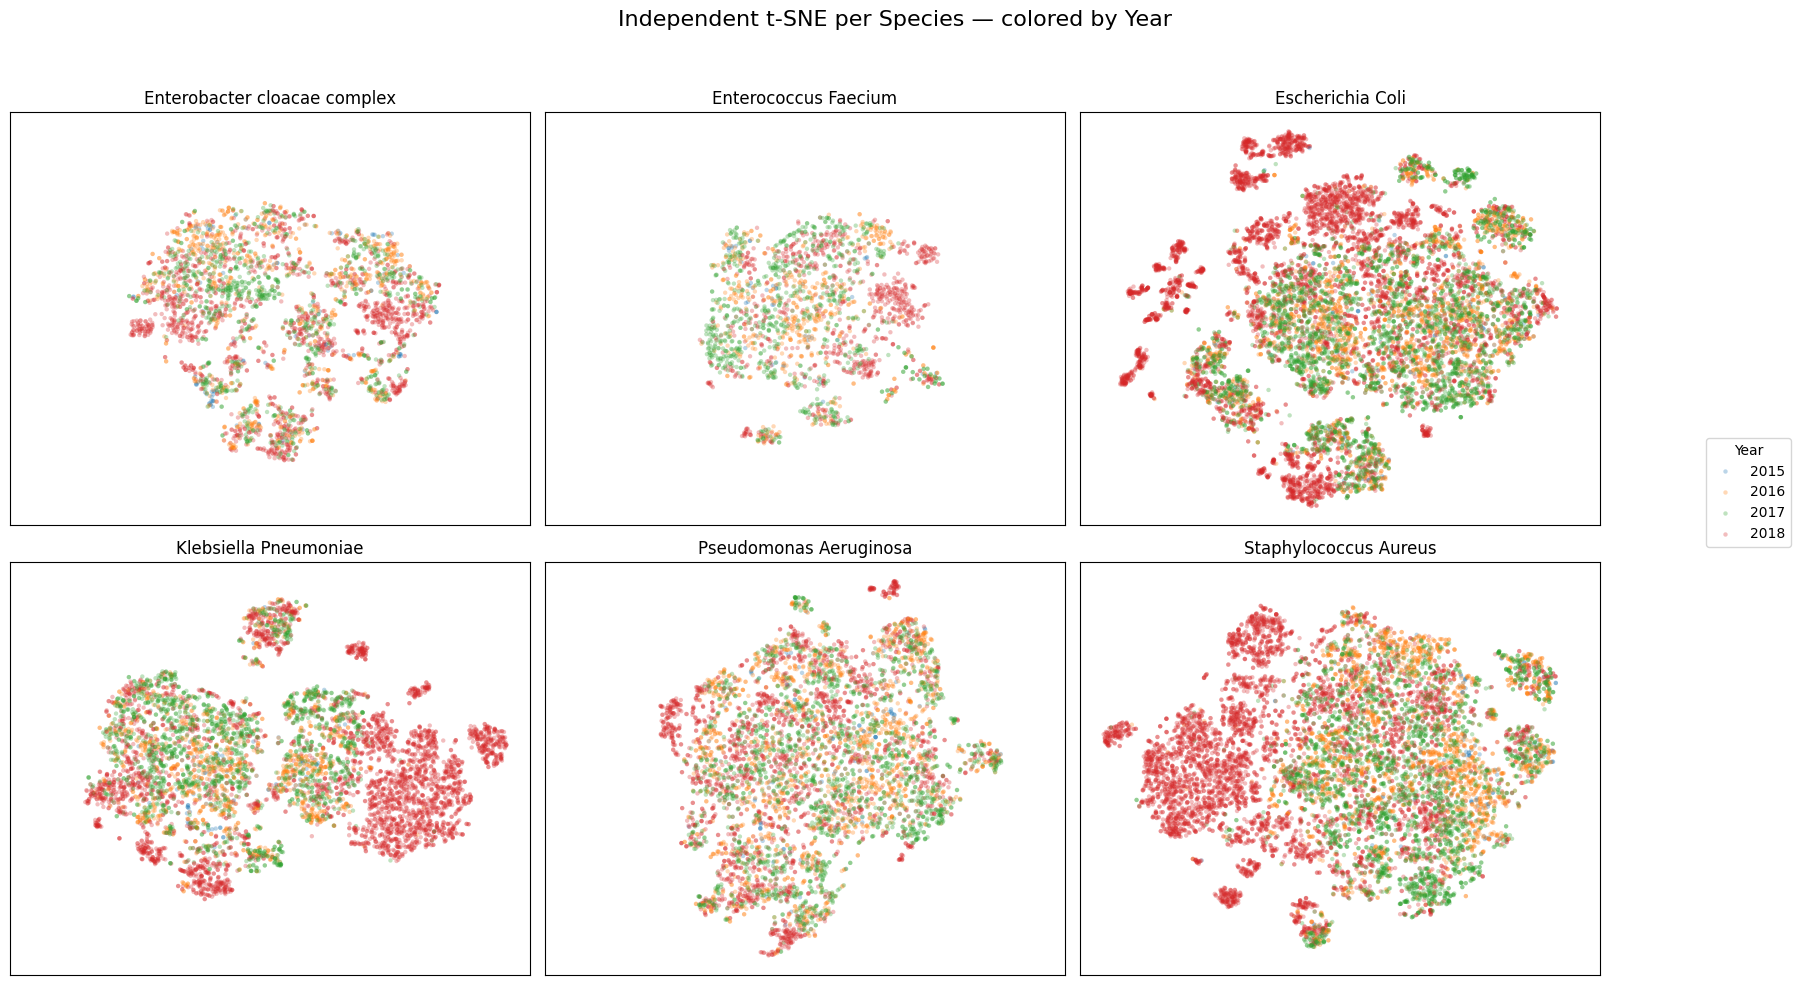

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

years_sorted = sorted(meta["year"].astype(str).unique(), key=lambda x: int(x))
palette_year_dict = {y: palette_year[i % len(palette_year)] for i, y in enumerate(years_sorted)}

for i, sp in enumerate(species_sorted):
    emb = tsne_results_year[sp]["embedding"]
    y_year = tsne_results_year[sp]["year"]

    sns.scatterplot(
        x=emb[:, 0], y=emb[:, 1],
        hue=y_year,
        hue_order=years_sorted,
        palette=palette_year_dict,
        s=10, linewidth=0, ax=axes[i], alpha=0.3
    )

    axes[i].set_title(sp.replace("_", " "), fontsize=12)
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].legend_.remove()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Year")

plt.suptitle("Independent t-SNE per Species — colored by Year", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()